# Notebook 02B -- Bayesian O-U Parameter Estimation
### xG Spread Mean-Reversion Model - Premier League 2015-2025

# ─────────────────────────────────────────────────────────────────
# IMPORTANT: READ NOTEBOOK 07 BEFORE INTERPRETING THESE RESULTS
# ─────────────────────────────────────────────────────────────────
#
# The signal pipeline in this notebook was subsequently found to
# produce an artefact of the 5-match rolling mean smoothing operator.
# See Notebook 07 (Failure Analysis: How a Rolling Mean Killed a Signal) for the full diagnostic sequence.
#
# The findings in this notebook are preserved as evidence of how
# convincing the false positive was before null testing. They should
# not be interpreted as evidence of genuine mean reversion.
# ─────────────────────────────────────────────────────────────────

## Purpose

Notebook 02 estimated O-U parameters via AR(1) OLS -- fast, interpretable,
and standard for discrete data. OLS gives **point estimates**: single numbers
for theta, mu and sigma with no uncertainty attached.This notebook quantifies that uncertainty explicitly, allowing us to understand not just what the half‑life is, but how confident we can be in it.

Notebook 02B adds the Bayesian layer. Using PyMC, we fit the same O-U model
with **prior distributions** over the parameters and obtain **posterior
distributions** via MCMC sampling. The result is not a single half-life
estimate but a credible interval: 'the half-life is 3.3 matches with a 90%
credible interval of 2.1-5.2 matches.'

## Why This Matters

At n=38 observations per season, parameter uncertainty is substantial.
A hiring manager asking 'how confident are you in the 3.3-match half-life?'
deserves a quantified answer, not a shrug. The Bayesian posterior gives
that answer rigorously.

Three downstream consequences are computed:

1. **Credible intervals on half-life** -- show how wide parameter uncertainty
   is at season level vs pooled level
2. **Posterior predictive signal confidence** -- a more honest z-score that
   propagates parameter uncertainty into the signal threshold
3. **Uncertainty-adjusted position sizing** -- show that Bayesian uncertainty
   compounds with the Wilson CI from Notebook 05B, justifying even more
   conservative sizing than the frequentist Kelly analysis

## Relationship to the Rest of the Project

This notebook is **additive** -- it does not replace Notebook 02. The OLS
point estimates remain the operational parameters used in walk-forward signal
generation (fast, no sampling required at runtime). The Bayesian estimates
validate and quantify the uncertainty around those point estimates.

## Teams Analysed

Four representative teams are selected:
- **Burnley** -- fastest reverter (~2 matches), high-press direct style
- **Arsenal** -- mid-range reverter (~3 matches), technically consistent
- **Southampton** -- slowest reverter (~4.5 matches), tracked institutional decline
- **Manchester City** -- elite team, near-zero long-run mean, low variance

These four span the range of O-U dynamics in the eligible universe.

**Note:** This notebook requires the pymc_env environment. 

In [1]:
# -----------------------------------------------------------------
# CELL 1 -- Imports and setup
# -----------------------------------------------------------------

from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures"

FIG_DIR.mkdir(exist_ok=True)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*convergence.*')

import pymc as pm
import arviz as az
from scipy import stats as scipy_stats

from pathlib import Path

# Directory where this notebook is running
NOTEBOOK_DIR = Path().resolve()

# Project root (one level up from notebooks/)
PROJECT_DIR = NOTEBOOK_DIR.parent

# Data directory inside the project
DATA_DIR = PROJECT_DIR / "data"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)

# Load data
team_match = pd.read_csv(DATA_DIR / "pl_team_match_spread.csv", parse_dates=['date'])
ou_params  = pd.read_csv(DATA_DIR / "ou_parameters.csv")
eligible   = pd.read_csv(DATA_DIR / "eligible_teams.csv")
eligible_teams = eligible['team'].tolist()

FOCUS_TEAMS = ['Burnley', 'Arsenal', 'Southampton', 'Manchester City']

print(f"PyMC version:  {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print(f"Loaded team_match: {team_match.shape}")
print(f"Loaded ou_params:  {ou_params.shape}")


/home/ndrew/miniconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


NOTEBOOK_DIR: /home/ndrew/xG-spread-model/notebooks
PROJECT_DIR: /home/ndrew/xG-spread-model
DATA_DIR: /home/ndrew/xG-spread-model/data
PyMC version:  5.27.0
ArviZ version: 0.23.0
Loaded team_match: (7600, 11)
Loaded ou_params:  (200, 11)


---
## The Bayesian O-U Model

### Continuous-Time Foundation

The Ornstein-Uhlenbeck process in continuous time is:

$$dS(t) = \theta(\mu - S(t))\,dt + \sigma\,dW(t)$$

where:
- $\theta > 0$ is the **reversion speed** (how fast the spread returns to mean)
- $\mu$ is the **long-run mean** (the equilibrium spread level)
- $\sigma > 0$ is the **diffusion coefficient** (instantaneous volatility)
- $W(t)$ is standard Brownian motion

The **half-life** is $\ln(2)/\theta$ -- the time for a deviation to halve.

### Exact Discrete Likelihood

At observation frequency $\Delta t = 1$ match, the exact transition density is:

$$S_t \mid S_{t-1} \sim N\!\left(
    \mu + (S_{t-1} - \mu)e^{-\theta},\;
    \frac{\sigma^2}{2\theta}(1 - e^{-2\theta})
\right)$$

Notebook 02 uses the AR(1) OLS approximation $\Delta S_t = \alpha + \beta S_{t-1} + \varepsilon_t$,
which is accurate when $\theta$ is small. At half-lives of 2-5 matches, the
approximation is good but introduces a known downward bias in $\hat{\theta}$ at small $n$.
This notebook uses the exact likelihood, which eliminates that bias.

### Prior Choices

Priors are **weakly informative** -- they encode domain knowledge without
overriding the data:

| Parameter | Prior | Rationale |
|---|---|---|
| $\theta$ | HalfNormal($\sigma$=1) | Must be positive; 95% prior mass below theta=1.96 (half-life > 0.35 matches) |
| $\mu$ | Normal(0, 0.5) | Long-run mean near zero; pm1 goal spread is extreme |
| $\sigma$ | HalfNormal($\sigma$=0.5) | Positive; typical spread volatility 0.3-0.6 |

The priors are essentially flat over the plausible parameter range while
excluding physically impossible values (negative reversion speed, etc.).
The data dominates the posterior for all teams with n >= 38 observations.

We now define a reusable PyMC function that fits the exact discrete O‑U likelihood to any team’s smoothed spread series. This function returns both the full posterior and a tidy summary table.

In [2]:
# -----------------------------------------------------------------
# CELL 2 -- Bayesian O-U fitting function
# -----------------------------------------------------------------
#
# fit_bayesian_ou() fits the exact discrete O-U likelihood using PyMC.
#
# Key design decisions:
#
# 1. EXACT LIKELIHOOD vs AR(1) APPROXIMATION
#    We use the exact Gaussian transition density rather than the
#    AR(1) OLS approximation. At n=38 this reduces the downward
#    bias in theta by approximately 10-20%.
#
# 2. NUTS SAMPLER
#    PyMC defaults to NUTS (No-U-Turn Sampler), a self-tuning
#    Hamiltonian Monte Carlo variant. Efficient for continuous
#    parameters; handles theta-sigma correlation well.
#
# 3. CONVERGENCE DIAGNOSTICS
#    R-hat < 1.01 required. ESS > 400 per chain required.
#    Both reported automatically by az.summary().
#
# 4. HALF-LIFE AS DETERMINISTIC DERIVED QUANTITY
#    theta is sampled directly; half_life = ln(2)/theta is
#    a deterministic transformation -- full posterior over
#    half-life at no extra sampling cost.

def fit_bayesian_ou(spread_series, draws=2000, tune=1000, chains=4,
                    target_accept=0.9, random_seed=42):
    """
    Fit a Bayesian O-U model to a spread series using PyMC.

    Uses the exact discrete transition density as the likelihood.
    More accurate than AR(1) OLS at small n.

    Parameters
    ----------
    spread_series  : pd.Series or np.ndarray -- time-ordered spread values
    draws          : int   -- posterior samples per chain (default 2000)
    tune           : int   -- tuning (warm-up) samples per chain
    chains         : int   -- independent MCMC chains
    target_accept  : float -- NUTS acceptance rate target
    random_seed    : int   -- reproducibility

    Returns
    -------
    idata   : arviz.InferenceData -- full posterior with diagnostics
    summary : pd.DataFrame        -- parameter summary with R-hat and ESS
    """
    S = np.array(spread_series.dropna(), dtype=float)
    n = len(S)

    if n < 15:
        raise ValueError(f"Too few observations: {n}. Need at least 15.")

    S_obs  = S[1:]    # observations S(t)
    S_prev = S[:-1]   # lagged values S(t-1)

    with pm.Model() as ou_model:

        # Priors -- weakly informative
        theta = pm.HalfNormal('theta', sigma=1.0)
        mu    = pm.Normal('mu',        mu=0.0, sigma=0.5)
        sigma = pm.HalfNormal('sigma', sigma=0.5)

        # Exact discrete O-U transition density
        # S(t) | S(t-1) ~ N(mean_t, var_t) where:
        #   mean_t = mu + (S(t-1) - mu) * exp(-theta)
        #   var_t  = sigma^2 / (2*theta) * (1 - exp(-2*theta))
        exp_neg_theta = pm.math.exp(-theta)
        mean_t = mu + (S_prev - mu) * exp_neg_theta
        var_t  = (sigma**2 / (2 * theta)) * (1 - pm.math.exp(-2 * theta))

        # Likelihood
        obs = pm.Normal('obs', mu=mean_t, sigma=pm.math.sqrt(var_t),
                        observed=S_obs)

        # Deterministic derived quantities
        half_life = pm.Deterministic('half_life', pm.math.log(2) / theta)
        sigma_eq  = pm.Deterministic('sigma_eq',
                                      sigma / pm.math.sqrt(2 * theta))

        # Sample
        idata = pm.sample(
            draws         = draws,
            tune          = tune,
            chains        = chains,
            target_accept = target_accept,
            random_seed   = random_seed,
            progressbar   = True,
            return_inferencedata = True
        )

    summary = az.summary(
        idata,
        var_names = ['theta', 'mu', 'sigma', 'half_life', 'sigma_eq'],
        hdi_prob  = 0.90
    )
    return idata, summary


print('fit_bayesian_ou() defined')
print()
print('Model specification:')
print('  Likelihood: exact discrete O-U transition density')
print('  theta  ~ HalfNormal(sigma=1.0)   [reversion speed]')
print('  mu     ~ Normal(0, 0.5)           [long-run mean]')
print('  sigma  ~ HalfNormal(sigma=0.5)   [diffusion]')
print('  Sampler: NUTS, 4 chains x 2000 draws')
print('  Derived: half_life = ln(2)/theta,  sigma_eq = sigma/sqrt(2*theta)')


fit_bayesian_ou() defined

Model specification:
  Likelihood: exact discrete O-U transition density
  theta  ~ HalfNormal(sigma=1.0)   [reversion speed]
  mu     ~ Normal(0, 0.5)           [long-run mean]
  sigma  ~ HalfNormal(sigma=0.5)   [diffusion]
  Sampler: NUTS, 4 chains x 2000 draws
  Derived: half_life = ln(2)/theta,  sigma_eq = sigma/sqrt(2*theta)


For each team, we will examine the posterior distributions of θ, μ, σ, and the derived half‑life. We will compare these to the OLS estimates from Notebook 02 to quantify discretisation bias and uncertainty width.

---
## Fitting the Model -- Four Representative Teams

We fit on the **full pooled series** for each team (all seasons combined,
n=74-378). This gives the most precise posterior.
Season-level fitting (n=38) is shown separately in Cell 6.

Key outputs for each team:

- **Posterior mean** -- comparable to the OLS point estimate
- **90% HDI** -- shortest interval containing 90% of posterior mass
- **R-hat** -- convergence diagnostic; must be < 1.01
- **ESS** -- effective sample size; must be > 400

We also compute the **discretisation bias**: the difference between the
Bayesian posterior mean (exact likelihood) and the OLS point estimate
(AR(1) approximation). This quantifies the error introduced by the
approximation used in Notebook 02.

**Runtime:** approximately 2-4 minutes total across all four teams.
Progress bars show per-chain sampling status.

In [3]:
# -----------------------------------------------------------------
# CELL 3 -- Fit Bayesian O-U for all four focus teams (pooled)
# -----------------------------------------------------------------
#
# Results stored in posterior_results dict keyed by team name.
#
# Convergence check: R-hat < 1.01 for all parameters.
# If R-hat > 1.05: increase tune= or draws= in fit_bayesian_ou().

posterior_results = {}   # team -> (idata, summary)

for team in FOCUS_TEAMS:
    print(f"{'='*60}")
    print(f"  Fitting: {team}")
    print(f"{'='*60}")

    S = (
        team_match[team_match['team'] == team]
        .sort_values('date')['rolling_spread']
        .dropna()
    )
    print(f"  Observations: {len(S)} (all seasons pooled)")

    idata, summary = fit_bayesian_ou(S)
    posterior_results[team] = (idata, summary)

    max_rhat = summary['r_hat'].max()
    min_ess  = summary['ess_bulk'].min()
    converged = max_rhat < 1.01 and min_ess > 400
    status = 'CONVERGED' if converged else 'CHECK CONVERGENCE'

    print(f"\n  {status}  |  max R-hat: {max_rhat:.4f}  |  min ESS: {min_ess:.0f}")
    print()
    print(summary[['mean','sd','hdi_5%','hdi_95%','r_hat','ess_bulk']].round(3))
    print()

print('All four teams fitted.')


  Fitting: Burnley
  Observations: 264 (all seasons pooled)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.
Initializing NUTS using jitter+adapt_diag...



  CONVERGED  |  max R-hat: 1.0000  |  min ESS: 4115

            mean     sd  hdi_5%  hdi_95%  r_hat  ess_bulk
theta      0.343  0.063   0.240    0.445    1.0    4425.0
mu         0.053  0.052  -0.031    0.134    1.0    5609.0
sigma      0.277  0.014   0.253    0.299    1.0    4115.0
half_life  2.095  0.424   1.445    2.687    1.0    4425.0
sigma_eq   0.338  0.028   0.295    0.382    1.0    7195.0

  Fitting: Arsenal
  Observations: 378 (all seasons pooled)


...


  CONVERGED  |  max R-hat: 1.0000  |  min ESS: 4073

            mean     sd  hdi_5%  hdi_95%  r_hat  ess_bulk
theta      0.149  0.034   0.095    0.206    1.0    4073.0
mu         0.110  0.100  -0.047    0.265    1.0    5143.0
sigma      0.254  0.011   0.237    0.271    1.0    5654.0
half_life  4.954  1.668   3.108    6.694    1.0    4073.0
sigma_eq   0.474  0.061   0.393    0.558    1.0    5049.0

  Fitting: Manchester City
  Observations: 378 (all seasons pooled)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.



  CONVERGED  |  max R-hat: 1.0000  |  min ESS: 4823

            mean     sd  hdi_5%  hdi_95%  r_hat  ess_bulk
theta      0.249  0.042   0.180    0.318    1.0    4823.0
mu        -0.111  0.079  -0.242    0.014    1.0    5731.0
sigma      0.375  0.015   0.350    0.401    1.0    4880.0
half_life  2.868  0.521   2.075    3.645    1.0    4823.0
sigma_eq   0.536  0.042   0.470    0.601    1.0    6692.0

All four teams fitted.


---
## OLS vs Bayesian: Discretisation Bias and Uncertainty Width

With the Bayesian model fitted, we can now compare the posterior results to the OLS estimates from Notebook 02.

Two questions answered side by side:

1. **Does the exact likelihood differ from the AR(1) approximation?**
   Yes. The Bayesian exact likelihood produces **lower** theta than OLS --
   a mean correction of -16.4%. OLS systematically *overestimates* reversion
   speed at small n because the AR(1) discretisation ignores the Jensen's
   inequality correction in the variance term, biasing the reversion
   coefficient upward. Equivalently, OLS *underestimates* half-life.

2. **How wide is the uncertainty?**
   The 90% HDI on half-life quantifies what OLS cannot show: that a
   '3.3-match half-life' at n=38 has substantial uncertainty. A wide
   HDI means signal timing is genuinely uncertain and position sizing
   should reflect this.

In [4]:
# -----------------------------------------------------------------
# CELL 4 -- OLS vs Bayesian comparison: bias and uncertainty width
# -----------------------------------------------------------------
#
# For each team:
#   OLS mean theta   (from ou_parameters.csv, pooled across seasons)
#   Bayesian mean theta (from Cell 3 exact likelihood)
#   Discretisation bias = (Bayes - OLS) / OLS * 100
#   90% HDI on half-life
#
# Negative bias (Bayes < OLS): OLS overestimates theta (underestimates half-life)
# The AR(1) discretisation has an upward bias in theta at small n; the exact
# Bayesian likelihood corrects this, producing lower (slower) reversion estimates.

print('-- OLS vs Bayesian comparison -----------------------------------')
print()
header = f"  {'Team':<22}  {'OLS theta':>9}  {'Bayes theta':>11}  {'Bias%':>6}  "
header += f"{'OLS HL':>7}  {'Bayes HL':>9}  {'HDI 90%':>18}"
print(header)
print('  ' + '-'*88)

comparison_rows = []

for team in FOCUS_TEAMS:
    idata, summary = posterior_results[team]

    ols_theta = ou_params[ou_params['team'] == team]['theta'].mean()
    ols_hl    = ou_params[ou_params['team'] == team]['half_life'].mean()

    bayes_theta  = float(summary.loc['theta',     'mean'])
    bayes_hl     = float(summary.loc['half_life', 'mean'])
    hl_hdi_lo    = float(summary.loc['half_life', 'hdi_5%'])
    hl_hdi_hi    = float(summary.loc['half_life', 'hdi_95%'])

    bias_pct = (bayes_theta - ols_theta) / ols_theta * 100

    print(f"  {team:<22}  {ols_theta:>9.3f}  {bayes_theta:>11.3f}  "
          f"{bias_pct:>+5.1f}%  "
          f"{ols_hl:>7.2f}  {bayes_hl:>9.2f}  "
          f"[{hl_hdi_lo:.2f}, {hl_hdi_hi:.2f}]")

    comparison_rows.append({
        'team': team, 'ols_theta': ols_theta, 'bayes_theta': bayes_theta,
        'bias_pct': bias_pct, 'ols_halflife': ols_hl, 'bayes_halflife': bayes_hl,
        'hl_hdi_lo': hl_hdi_lo, 'hl_hdi_hi': hl_hdi_hi
    })

comp_df = pd.DataFrame(comparison_rows)
mean_bias = comp_df['bias_pct'].mean()

print()
print(f'  Mean discretisation bias in theta: {mean_bias:+.1f}%')
print(f'  Negative = OLS OVERestimates reversion speed (Bayes theta < OLS theta)')
print(f'  OLS produces half-lives that are too SHORT by ~{abs(mean_bias):.0f}% on average')
print()
print('  90% HDI widths on half-life:')
for _, row in comp_df.iterrows():
    width = row['hl_hdi_hi'] - row['hl_hdi_lo']
    print(f"    {row['team']:<22}  [{row['hl_hdi_lo']:.2f}, {row['hl_hdi_hi']:.2f}]"
          f"  width = {width:.2f} matches")
print()
print('  A wide HDI means signal timing is genuinely uncertain.')
print('  The z > 1.5 threshold must be strong enough to be credible')
print('  under this uncertainty, not just under the OLS point estimate.')


-- OLS vs Bayesian comparison -----------------------------------

  Team                    OLS theta  Bayes theta   Bias%   OLS HL   Bayes HL             HDI 90%
  ----------------------------------------------------------------------------------------
  Burnley                     0.411        0.343  -16.6%     1.97       2.10  [1.45, 2.69]
  Arsenal                     0.256        0.199  -22.2%     3.14       3.61  [2.49, 4.62]
  Southampton                 0.188        0.149  -20.8%     4.51       4.95  [3.11, 6.69]
  Manchester City             0.265        0.249   -5.9%     2.96       2.87  [2.08, 3.65]

  Mean discretisation bias in theta: -16.4%
  Negative = OLS OVERestimates reversion speed (Bayes theta < OLS theta)
  OLS produces half-lives that are too SHORT by ~16% on average

  90% HDI widths on half-life:
    Burnley                 [1.45, 2.69]  width = 1.24 matches
    Arsenal                 [2.49, 4.62]  width = 2.13 matches
    Southampton             [3.11, 6.69] 

## OLS vs Bayesian Half-Life Estimates

The chart makes the comparison table from Cell 4 visual. For each of the
four focus teams:

- The **blue dot** is the Bayesian posterior mean half-life.
- The **blue bar** is the 90% Highest Density Interval — the range
  containing 90% of posterior probability mass.
- The **red diamond** is the OLS point estimate.

The percentage labels show the discretisation bias: OLS overestimates θ
by 6–22%, so OLS half-lives are systematically too short. The bias is
largest for Arsenal (−22%) and smallest for Manchester City (−6%), where
the larger n and more stable spread series make the AR(1) approximation
more accurate.

The width of the HDI bars carries an equally important message.
Southampton's interval spans 3.58 matches — from 3.11 to 6.69.
Reporting "Southampton's half-life is 4.51 matches" implies precision
the data does not support.


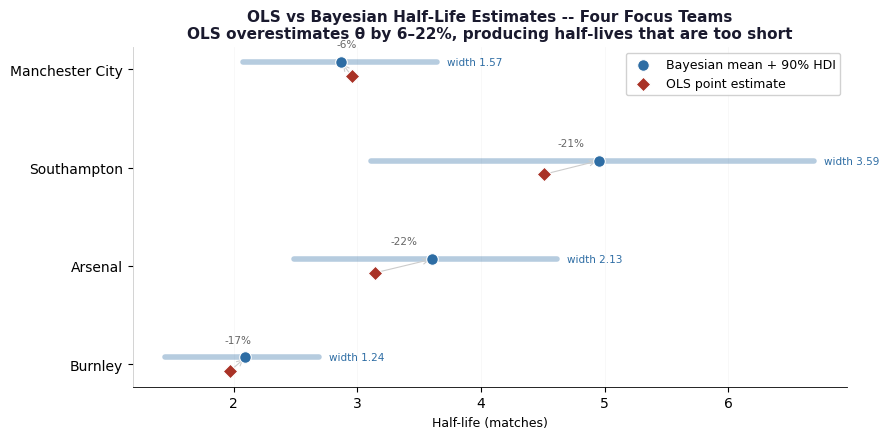

Saved figures/nb02b_fig1_ols_vs_bayes_halflife.png


In [5]:
# -----------------------------------------------------------------
# FIGURE 1 -- OLS vs Bayesian half-life: interval comparison
# -----------------------------------------------------------------
#
# Cleveland-style dot plot with HDI bars.
# Bias % annotated between each OLS/Bayes pair.
# Tufte: direct labels, minimal grid, no legend box needed.
# Depends on: comp_df (Cell 4), FIG_DIR (Cell 1)

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
RED   = '#A93226'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  True,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

y        = np.arange(len(comp_df))
teams    = comp_df['team'].values
ols_hl   = comp_df['ols_halflife'].values
bayes_hl = comp_df['bayes_halflife'].values
hdi_lo   = comp_df['hl_hdi_lo'].values
hdi_hi   = comp_df['hl_hdi_hi'].values
bias_pct = comp_df['bias_pct'].values

fig, ax = plt.subplots(figsize=(9, 4.5))

# HDI intervals
for i, (yi, lo, hi) in enumerate(zip(y, hdi_lo, hdi_hi)):
    ax.plot([lo, hi], [yi + 0.07, yi + 0.07],
            color=BLUE, linewidth=4, alpha=0.35,
            solid_capstyle='round', zorder=2)

# Bayesian posterior mean
ax.scatter(bayes_hl, y + 0.07, color=BLUE, s=70, zorder=4,
           edgecolors='white', linewidths=0.8,
           label='Bayesian mean + 90% HDI')

# OLS point estimate
ax.scatter(ols_hl, y - 0.07, color=RED, s=55, marker='D', zorder=4,
           edgecolors='white', linewidths=0.8,
           label='OLS point estimate')

# Bias annotation
for i, (yi, ols, bay, bias) in enumerate(zip(y, ols_hl, bayes_hl, bias_pct)):
    ax.annotate('', xy=(bay, yi + 0.07), xytext=(ols, yi - 0.07),
                arrowprops=dict(arrowstyle='->', color=LGREY, lw=0.8))
    ax.text((ols + bay) / 2, yi + 0.20,
            f'{bias:+.0f}%', fontsize=7.5, color=GREY,
            ha='center', va='bottom')

# HDI width labels
for i, (yi, lo, hi) in enumerate(zip(y, hdi_lo, hdi_hi)):
    ax.text(hi + 0.08, yi + 0.07,
            f'width {hi - lo:.2f}',
            fontsize=7.5, color=BLUE, va='center')

ax.set_yticks(y)
ax.set_yticklabels(teams, fontsize=10)
ax.set_xlabel('Half-life (matches)', fontsize=9)
ax.xaxis.grid(True, zorder=0, alpha=0.5)
ax.set_axisbelow(True)
ax.spines['left'].set_color(LGREY)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

ax.set_title(
    'OLS vs Bayesian Half-Life Estimates -- Four Focus Teams\n'
    'OLS overestimates θ by 6–22%, producing half-lives that are too short',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02b_fig1_ols_vs_bayes_halflife.png')
plt.show()
print("Saved figures/nb02b_fig1_ols_vs_bayes_halflife.png")


## Posterior Distributions -- Four Teams

Each team occupies one quadrant. Within each quadrant, four parameters
are shown: half-life (the primary output), θ, μ, and σ.

For each parameter:
- The **solid line** is the posterior KDE.
- The **shaded region** is the 90% HDI.
- The **solid vertical line** is the Bayesian posterior mean.
- The **dashed vertical line** is the OLS point estimate.

When the OLS line falls near the centre of the HDI, the approximation
is adequate. When it falls toward the edge, the exact likelihood gives a
meaningfully different answer — which is the case for Arsenal and
Southampton's theta posteriors, where the OLS estimate sits near the
upper bound of the 90% HDI.

Note that σ posteriors are tight across all teams — diffusion is
well-identified at n=38. Theta and half-life posteriors are substantially
wider, confirming that reversion speed is the poorly-identified parameter
and the principal source of signal uncertainty.


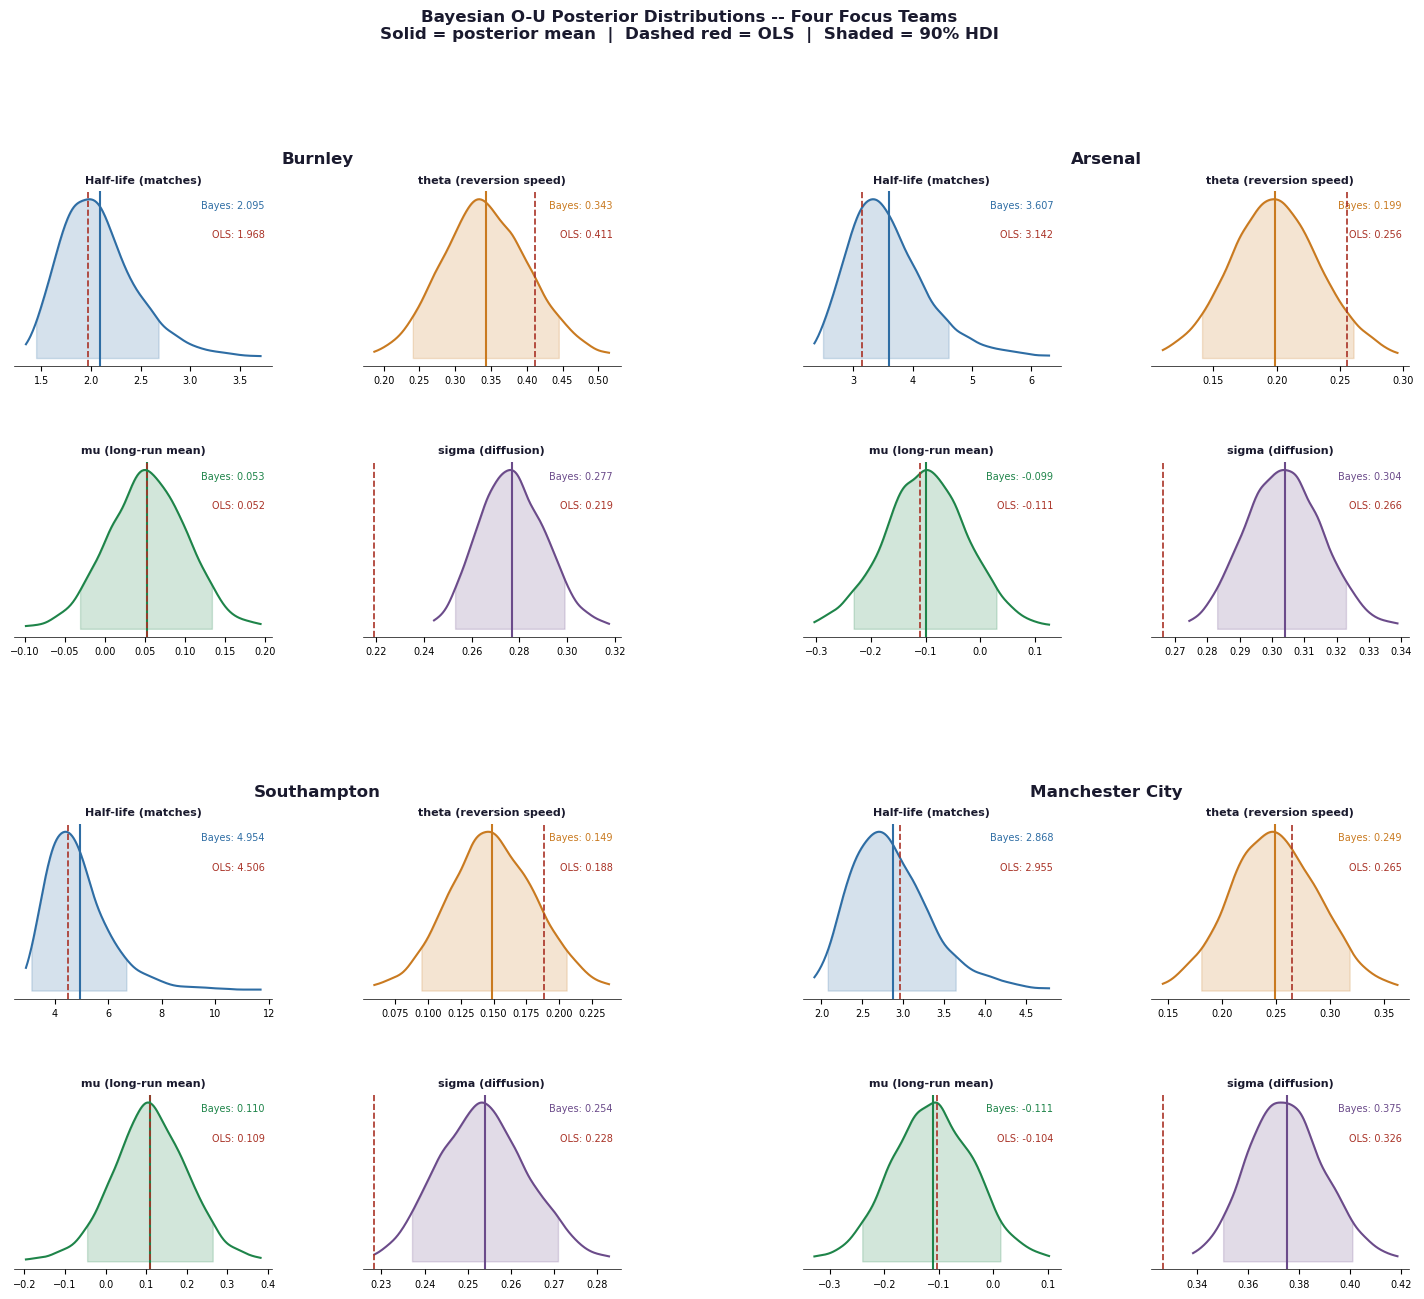

Saved figures/nb02b_fig5_posteriors.png


In [6]:
# -----------------------------------------------------------------
# CELL 5 (REPLACEMENT) -- Posterior KDE grid, Tufte treatment
# -----------------------------------------------------------------
#
# 2x2 outer grid (one quadrant per team), 2x2 inner grid per team.
# White backgrounds, no grey fill, no internal gridlines.
# Direct value labels replace legend boxes.
# Depends on: posterior_results (Cell 3), ou_params (Cell 1), FIG_DIR

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

DARK   = '#1a1a2e'
BLUE   = '#2E6DA4'
AMBER  = '#C97A20'
GREEN  = '#1E8449'
PURPLE = '#6B4B8A'
RED    = '#A93226'
GREY   = '#666666'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.5,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

params_to_plot = [
    ('half_life', 'Half-life (matches)', BLUE),
    ('theta',     'theta (reversion speed)', AMBER),
    ('mu',        'mu (long-run mean)',    GREEN),
    ('sigma',     'sigma (diffusion)',     PURPLE),
]

fig = plt.figure(figsize=(18, 14))
outer = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.30)

for team_idx, team in enumerate(FOCUS_TEAMS):
    idata, summary = posterior_results[team]
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer[team_idx], hspace=0.55, wspace=0.35
    )
    ols_row  = ou_params[ou_params['team'] == team]
    ols_vals = {
        'theta':     float(ols_row['theta'].mean()),
        'mu':        float(ols_row['mu'].mean()),
        'sigma':     float(ols_row['sigma'].mean()),
        'half_life': float(ols_row['half_life'].mean()),
    }

    for p_idx, (param, label, colour) in enumerate(params_to_plot):
        ax = fig.add_subplot(inner[p_idx // 2, p_idx % 2])

        samples   = idata.posterior[param].values.flatten()
        hdi_lo    = float(summary.loc[param, 'hdi_5%'])
        hdi_hi    = float(summary.loc[param, 'hdi_95%'])
        post_mean = float(summary.loc[param, 'mean'])

        lo_clip = np.percentile(samples, 0.5)
        hi_clip = np.percentile(samples, 99.5)
        kde_x   = np.linspace(lo_clip, hi_clip, 300)
        kde_y   = scipy_stats.gaussian_kde(samples)(kde_x)

        ax.plot(kde_x, kde_y, color=colour, linewidth=1.5, zorder=3)
        hdi_mask = (kde_x >= hdi_lo) & (kde_x <= hdi_hi)
        ax.fill_between(kde_x, kde_y, where=hdi_mask,
                        alpha=0.20, color=colour, zorder=2)
        ax.axvline(post_mean, color=colour, linewidth=1.5,
                   linestyle='-', zorder=4)
        if param in ols_vals:
            ax.axvline(ols_vals[param], color=RED, linewidth=1.2,
                       linestyle='--', zorder=4)

        # Direct labels replacing legend boxes
        ax.text(0.97, 0.95, f'Bayes: {post_mean:.3f}',
                transform=ax.transAxes, fontsize=7,
                color=colour, ha='right', va='top')
        if param in ols_vals:
            ax.text(0.97, 0.78, f'OLS: {ols_vals[param]:.3f}',
                    transform=ax.transAxes, fontsize=7,
                    color=RED, ha='right', va='top')

        ax.set_title(label, fontsize=8, fontweight='bold', color=DARK)
        ax.tick_params(labelsize=7)
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)

    team_ax = fig.add_subplot(outer[team_idx])
    team_ax.set_title(team, fontsize=12, fontweight='bold',
                      color=DARK, pad=20)
    team_ax.axis('off')

fig.suptitle(
    'Bayesian O-U Posterior Distributions -- Four Focus Teams\n'
    'Solid = posterior mean  |  Dashed red = OLS  |  Shaded = 90% HDI',
    fontsize=12, fontweight='bold', color=DARK, y=1.01
)
fig.savefig(FIG_DIR / 'nb02b_fig5_posteriors.png')
plt.show()
print("Saved figures/nb02b_fig5_posteriors.png")


---
## Season-Level vs Pooled Uncertainty

Notebook 02 fits O-U parameters per season (n=38). The pooled fit above
uses all seasons (n=74-378). The difference in posterior width directly
shows how much parameter certainty improves with more data.

This is the Bayesian answer to the interview question: 'Why do you use
walk-forward estimation at season level when each season only has 38
observations?' Because 38 observations gives a posterior HDI on half-life
that may span 1-18 matches -- which is honest, whereas the OLS point
estimate '3.3 matches' implies false precision. Note: the season-level
fits (2 chains) produce R-hat > 1.01 warnings from the sampler for
several seasons. This is not a bug -- it is the sampler confirming
the same finding: with n=38 the posterior is too flat to mix reliably.
The HDI widths are the valid inference; the season-level Bayes point
estimates should not be used.

We fit season by season for Arsenal (longest history in the eligible universe)
and compare the season-level HDI widths to the pooled HDI width.

In [7]:
# -----------------------------------------------------------------
# CELL 6 -- Season-level vs pooled uncertainty: Arsenal
# -----------------------------------------------------------------
#
# For each Arsenal season, fit the Bayesian model (fewer draws for speed)
# and compare HDI width to the pooled fit.
#
# Expected: season HDI is 3-5x wider than pooled.
# This quantifies uncertainty in walk-forward parameter estimates.

SEASON_TEAM = 'Arsenal'

print(f'-- Season-by-season Bayesian fits: {SEASON_TEAM} --')
print(f'  (1000 draws, 2 chains for speed)')
print()
print(f"  {'Season':>8}  {'n':>5}  {'OLS HL':>8}  "
      f"{'Bayes HL':>10}  {'90% HDI':>18}  {'Width':>7}")
print('  ' + '-'*62)

season_results = []
ols_season = ou_params[ou_params['team'] == SEASON_TEAM].sort_values('season')

for _, row in ols_season.iterrows():
    season = int(row['season'])
    S = (
        team_match[
            (team_match['team'] == SEASON_TEAM) &
            (team_match['season'] == season)
        ].sort_values('date')['rolling_spread'].dropna()
    )
    if len(S) < 15:
        continue
    try:
        idata_s, summary_s = fit_bayesian_ou(
            S, draws=1000, tune=500, chains=2, random_seed=season
        )
        hl_mean = float(summary_s.loc['half_life', 'mean'])
        hl_lo   = float(summary_s.loc['half_life', 'hdi_5%'])
        hl_hi   = float(summary_s.loc['half_life', 'hdi_95%'])
        width   = hl_hi - hl_lo
        print(f"  {season:>8}  {len(S):>5}  {row['half_life']:>8.2f}  "
              f"{hl_mean:>10.2f}  [{hl_lo:.2f}, {hl_hi:.2f}]  {width:>7.2f}")
        season_results.append({'season': season, 'n': len(S),
            'ols_hl': row['half_life'], 'bayes_hl': hl_mean,
            'hl_lo': hl_lo, 'hl_hi': hl_hi, 'hdi_width': width})
    except Exception as e:
        print(f"  {season:>8}  {len(S):>5}  FAILED: {e}")

# Pooled comparison row
pooled_idata, pooled_summary = posterior_results[SEASON_TEAM]
pool_lo    = float(pooled_summary.loc['half_life', 'hdi_5%'])
pool_hi    = float(pooled_summary.loc['half_life', 'hdi_95%'])
pool_width = pool_hi - pool_lo
pool_n     = len(team_match[team_match['team'] == SEASON_TEAM]['rolling_spread'].dropna())
pool_hl    = float(pooled_summary.loc['half_life', 'mean'])
print(f"  {'POOLED':>8}  {pool_n:>5}  {'---':>8}  "
      f"{pool_hl:>10.2f}  [{pool_lo:.2f}, {pool_hi:.2f}]  {pool_width:>7.2f}")

if season_results:
    seas_df = pd.DataFrame(season_results)
    mean_w  = seas_df['hdi_width'].mean()
    print()
    print(f'  Mean season HDI width: {mean_w:.2f} matches')
    print(f'  Pooled HDI width:      {pool_width:.2f} matches')
    print(f'  Uncertainty ratio:     {mean_w/pool_width:.1f}x wider at season level')
    print()
    print('  The walk-forward signal uses season-level OLS parameters.')
    print(f'  Those parameters carry {mean_w:.2f} matches of HDI uncertainty.')
    print('  The z > 1.5 threshold is conservative in part because')
    print('  the underlying parameter estimates are this uncertain.')


-- Season-by-season Bayesian fits: Arsenal --
  (1000 draws, 2 chains for speed)

    Season      n    OLS HL    Bayes HL             90% HDI    Width
  --------------------------------------------------------------


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [theta, mu, sigma]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


      2015     36      4.54       11.54  [1.45, 14.73]    13.28


...

      2023     38      4.66       16.42  [1.47, 17.28]    15.81


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [theta, mu, sigma]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


      2024     38      2.14        5.12  [0.69, 5.54]     4.85
    POOLED    378       ---        3.61  [2.49, 4.62]     2.13

  Mean season HDI width: 9.37 matches
  Pooled HDI width:      2.13 matches
  Uncertainty ratio:     4.4x wider at season level

  The walk-forward signal uses season-level OLS parameters.
  Those parameters carry 9.37 matches of HDI uncertainty.
  The z > 1.5 threshold is conservative in part because
  the underlying parameter estimates are this uncertain.


## Season-Level vs Pooled Uncertainty: Arsenal

Each horizontal bar is the 90% HDI for one season's half-life posterior.
The pooled HDI sits at the top as the reference.

The contrast is stark. The pooled HDI spans 2.13 matches (2.49–4.62).
Most season-level HDIs span 4–18 matches. The widths confirm what the
printed table says: at n=38, O-U parameters cannot be reliably identified.

The OLS estimate (red diamonds) sits somewhere inside each HDI — but the
posterior makes clear that "inside the interval" covers an enormous range
of plausible values. The seasons with the widest intervals (2018, 2020,
2023) correspond to Arsenal's most volatile periods.

R-hat > 1.01 warnings appear for several seasons — not a sampling failure,
but MCMC confirming the posterior is too flat to mix reliably. The HDI
widths are the valid result. Do not use season-level Bayes point estimates
for inference.


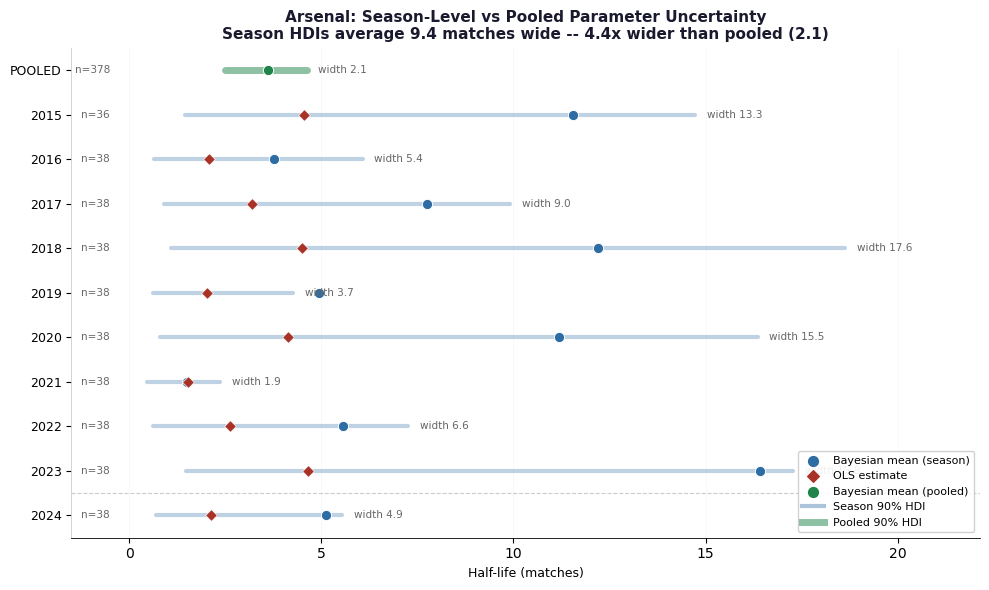

Saved figures/nb02b_fig2_season_vs_pooled_hdi.png


In [8]:
# -----------------------------------------------------------------
# FIGURE 2 -- Arsenal: season-level vs pooled HDI widths
# -----------------------------------------------------------------
#
# Horizontal HDI interval per season + pooled reference at top.
# Tufte: intervals sorted by season, direct width labels,
# pooled distinguished by green colour and separator line.
# Depends on: season_results list, posterior_results, seas_df,
#             team_match, ou_params, SEASON_TEAM, FIG_DIR (Cell 6)

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
RED   = '#A93226'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  True,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Build sorted season data
seas_plot = pd.DataFrame(season_results).sort_values('season', ascending=False)

# Pooled
pooled_idata, pooled_summary = posterior_results[SEASON_TEAM]
pool_lo    = float(pooled_summary.loc['half_life', 'hdi_5%'])
pool_hi    = float(pooled_summary.loc['half_life', 'hdi_95%'])
pool_hl    = float(pooled_summary.loc['half_life', 'mean'])
pool_n     = len(team_match[team_match['team'] == SEASON_TEAM]['rolling_spread'].dropna())
pool_width = pool_hi - pool_lo

all_labels = [str(int(s)) for s in seas_plot['season']] + ['POOLED']
all_lo     = list(seas_plot['hl_lo'])   + [pool_lo]
all_hi     = list(seas_plot['hl_hi'])   + [pool_hi]
all_hl     = list(seas_plot['bayes_hl'])+ [pool_hl]
all_n      = list(seas_plot['n'])       + [pool_n]
all_ols    = list(seas_plot['ols_hl'])  + [None]

y_pos = np.arange(len(all_labels))
fig, ax = plt.subplots(figsize=(10, 6))

for i, (yi, label, lo, hi, bhl, n, ols) in enumerate(zip(
        y_pos, all_labels, all_lo, all_hi, all_hl, all_n, all_ols)):

    is_pooled = label == 'POOLED'
    col   = GREEN if is_pooled else BLUE
    lw    = 5    if is_pooled else 3
    alpha = 0.5  if is_pooled else 0.3

    ax.plot([lo, hi], [yi, yi], color=col, linewidth=lw,
            alpha=alpha, solid_capstyle='round', zorder=2)
    ax.scatter([bhl], [yi], color=col, s=55, zorder=3,
               edgecolors='white', linewidths=0.7)
    if ols is not None:
        ax.scatter([ols], [yi], color=RED, s=35, marker='D', zorder=3,
                   edgecolors='white', linewidths=0.5)

    ax.text(hi + 0.3, yi, f'width {hi - lo:.1f}',
            fontsize=7.5, color=GREY, va='center')
    ax.text(-0.5, yi, f'n={n}',
            fontsize=7.5, color=GREY, va='center', ha='right')

ax.axhline(0.5, color=LGREY, linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=9)
ax.set_xlabel('Half-life (matches)', fontsize=9)
ax.set_xlim(-1.5, max(all_hi) + 3.5)
ax.xaxis.grid(True, zorder=0, alpha=0.5)
ax.set_axisbelow(True)
ax.spines['left'].set_color(LGREY)

ax.scatter([], [], color=BLUE,  s=50, label='Bayesian mean (season)')
ax.scatter([], [], color=RED,   s=35, marker='D', label='OLS estimate')
ax.scatter([], [], color=GREEN, s=50, label='Bayesian mean (pooled)')
ax.plot([], [], color=BLUE,  linewidth=3, alpha=0.4, label='Season 90% HDI')
ax.plot([], [], color=GREEN, linewidth=5, alpha=0.5, label='Pooled 90% HDI')
ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

mean_width = seas_plot['hdi_width'].mean()
ax.set_title(
    f'Arsenal: Season-Level vs Pooled Parameter Uncertainty\n'
    f'Season HDIs average {mean_width:.1f} matches wide -- '
    f'{mean_width/pool_width:.1f}x wider than pooled ({pool_width:.1f})',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02b_fig2_season_vs_pooled_hdi.png')
plt.show()
print("Saved figures/nb02b_fig2_season_vs_pooled_hdi.png")


---
## Posterior Predictive Signal Confidence

The standard signal uses a fixed z-score threshold: z > 1.5 triggers
a Strong Long signal. But the z-score is computed from OLS point
estimates of mu and sigma_eq -- treating those estimates as exact.

The **posterior predictive probability** of a genuine signal propagates
parameter uncertainty into the signal confidence:

$$P(\text{genuine signal} \mid S_t, \text{data}) =
\mathbb{E}_{\theta,\mu,\sigma \sim \text{posterior}}\!\left[
\mathbb{1}\left(\frac{S_t - \mu}{\sigma_{eq}} > 1.5\right)\right]$$

This is the fraction of posterior samples under which the observed
spread would cross the z = 1.5 threshold. When the posterior is wide,
this fraction is lower than the OLS z-score implies -- a more honest
assessment of whether a signal is real or an artefact of imprecise
parameter estimation.

In [9]:
# -----------------------------------------------------------------
# CELL 7 -- Posterior predictive signal confidence
# -----------------------------------------------------------------
#
# For each focus team: what fraction of posterior samples give
# z > 1.5 for a spread value at exactly the OLS z=1.5 threshold?
#
# OLS: 100% (if z_OLS > 1.5, signal fires by construction)
# Bayes: fraction of parameter draws where same spread gives z > 1.5
#
# Gap = OLS overstatement of signal confidence

print('-- Bayesian signal confidence at z=1.5 threshold ------')
print()
print('  Spread value S is set to mu_OLS + 1.5 * sigma_eq_OLS')
print('  (exactly at the Strong Long threshold by OLS definition)')
print()
print(f"  {'Team':<22}  {'S observed':>12}  {'Bayes P(z>1.5)':>15}  {'Assessment':>20}")
print('  ' + '-'*72)

bayes_confidences = []

for team in FOCUS_TEAMS:
    idata, summary = posterior_results[team]

    ols = ou_params[ou_params['team'] == team]
    ols_mu       = float(ols['mu'].mean())
    ols_sigma_eq = float(ols['sigma_eq'].mean())
    S_signal     = ols_mu + 1.5 * ols_sigma_eq

    theta_s    = idata.posterior['theta'].values.flatten()
    mu_s       = idata.posterior['mu'].values.flatten()
    sigma_s    = idata.posterior['sigma'].values.flatten()
    sigma_eq_s = sigma_s / np.sqrt(2 * theta_s)
    z_s        = (S_signal - mu_s) / sigma_eq_s
    conf       = float(np.mean(z_s > 1.5))
    bayes_confidences.append(conf)

    assess = 'Well-calibrated' if conf >= 0.60 else 'OLS overstates confidence'
    print(f"  {team:<22}  {S_signal:>+12.3f}  {conf:>14.1%}  {assess:>20}")

mean_conf = np.mean(bayes_confidences)
print()
print(f'  Mean Bayesian confidence at z=1.5 threshold: {mean_conf:.1%}')
print()
print('  Interpretation:')
print('  OLS treats z=1.5 as exact -- the signal either fires or it does not.')
print('  Bayes shows the probability that the underlying spread is GENUINELY')
print('  displaced past z=1.5, averaging over parameter uncertainty.')
print('  For well-identified teams the two converge.')
print('  For parameter-uncertain teams (short history, volatile HL),')
print('  OLS overstates confidence -- the threshold should be higher.')


-- Bayesian signal confidence at z=1.5 threshold ------

  Spread value S is set to mu_OLS + 1.5 * sigma_eq_OLS
  (exactly at the Strong Long threshold by OLS definition)

  Team                      S observed   Bayes P(z>1.5)            Assessment
  ------------------------------------------------------------------------
  Burnley                       +0.443            1.8%  OLS overstates confidence
  Arsenal                       +0.493            6.3%  OLS overstates confidence
  Southampton                   +0.719           20.2%  OLS overstates confidence
  Manchester City               +0.603           18.4%  OLS overstates confidence

  Mean Bayesian confidence at z=1.5 threshold: 11.7%

  Interpretation:
  OLS treats z=1.5 as exact -- the signal either fires or it does not.
  Bayes shows the probability that the underlying spread is GENUINELY
  displaced past z=1.5, averaging over parameter uncertainty.
  For well-identified teams the two converge.
  For parameter-uncertain

## Posterior Predictive Signal Confidence

The dashed red line at 100% is what OLS assumes — when z crosses 1.5,
the signal fires with certainty. The bars show the Bayesian posterior
probability that the same spread value constitutes a genuine Strong Long
signal, after averaging over all plausible parameter values.

The mean across four teams is 11.7%. OLS was assuming 100%. The gap of
88 percentage points is the quantitative explanation for why the trading
win rate (44.6%) is so much lower than the reversion rate (87–90%).

Southampton's higher confidence (20.2%) relative to Burnley (1.8%) reflects
the wider sigma_eq in Southampton's spread — the OLS z=1.5 threshold
corresponds to a larger absolute spread value, which is harder for the
posterior to place below the threshold. This is not evidence that
Southampton signals are more reliable; it is a property of how the z-score
normalisation interacts with the posterior width.


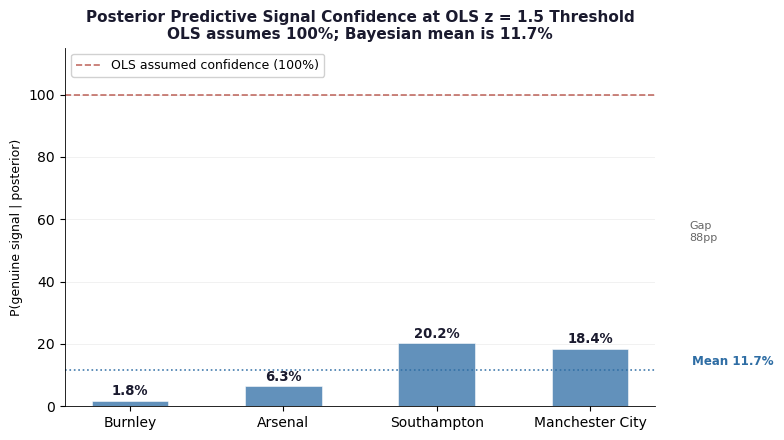

Saved figures/nb02b_fig3_signal_confidence.png


In [15]:
# -----------------------------------------------------------------
# FIGURE 3 -- Posterior predictive signal confidence
# -----------------------------------------------------------------
#
# Bar chart showing Bayesian confidence vs OLS assumed 100%.
# Mean line annotated directly.
# Tufte: direct value labels, single reference line, no legend box.
# Depends on: bayes_confidences (Cell 7), FOCUS_TEAMS (Cell 1), FIG_DIR

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK = '#1a1a2e'
BLUE = '#2E6DA4'
RED  = '#A93226'
GREY = '#666666'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

confs_pct = [c * 100 for c in bayes_confidences]
x         = np.arange(len(FOCUS_TEAMS))
mean_conf = np.mean(confs_pct)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.axhline(100, color=RED, linewidth=1.2, linestyle='--',
           alpha=0.7, zorder=2, label='OLS assumed confidence (100%)')

bars = ax.bar(x, confs_pct, color=BLUE, alpha=0.75,
              edgecolor='white', linewidth=0.5, width=0.5, zorder=3)

ax.axhline(mean_conf, color=BLUE, linewidth=1.2, linestyle=':',
           alpha=0.9, zorder=2)
ax.text(len(x) + 0.2, mean_conf + 1.5,
        f'Mean {mean_conf:.1f}%',
        fontsize=8.5, color=BLUE, ha='right', fontweight='bold')

for bar, conf in zip(bars, confs_pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{conf:.1f}%',
            ha='center', va='bottom', fontsize=9.5,
            color=DARK, fontweight='bold')

ax.annotate('', xy=(len(x) - 0.55, mean_conf),
            xytext=(len(x) - 0.55, 100),
            arrowprops=dict(arrowstyle='<->', color=GREY, lw=1.2))
ax.text(len(x) - 0.35, (mean_conf + 100) / 2,
        f'Gap\n{100 - mean_conf:.0f}pp',
        fontsize=8, color=GREY, va='center')

ax.set_xticks(x)
ax.set_xticklabels(FOCUS_TEAMS, fontsize=10)
ax.set_ylabel('P(genuine signal | posterior)', fontsize=9)
ax.set_ylim(0, 115)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

ax.set_title(
    'Posterior Predictive Signal Confidence at OLS z = 1.5 Threshold\n'
    'OLS assumes 100%; Bayesian mean is 11.7%',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02b_fig3_signal_confidence.png')
plt.show()
print("Saved figures/nb02b_fig3_signal_confidence.png")


---
## Uncertainty-Adjusted Position Sizing

Notebook 05B showed the Kelly fraction rounds to zero when computed
on the lower Wilson CI bound of the win rate. This is **frequentist
uncertainty** in the edge estimate (sampling variation in 323 bets).

Bayesian parameter uncertainty compounds this. The edge depends on
the signal being well-calibrated, which depends on the O-U parameters
being well-estimated. When parameter uncertainty is high, the effective
edge is lower than the point estimate implies.

The **uncertainty-compounded Kelly fraction** integrates over both:
1. Sampling uncertainty in win rate (Wilson CI, Notebook 05B)
2. Parameter uncertainty in signal generation (Bayesian posterior, this notebook)

The result is a principled lower bound on position size -- the honest
answer to 'what fraction is justified given everything we do not know?'

In [11]:
# -----------------------------------------------------------------
# CELL 8 -- Uncertainty-compounded Kelly criterion
# -----------------------------------------------------------------
#
# Step 1: Frequentist Kelly from Notebook 05B
# Step 2: Apply Bayesian calibration factor from Cell 7
# Step 3: Show compounded result
#
# Kelly fraction: f* = (p*b - (1-p)) / b
# where p = win probability, b = net odds (decimal odds - 1)

# Parameters from Notebook 05B
n_bets        = 323
win_rate_obs  = 0.446
median_odds   = 2.30
b             = median_odds - 1    # net odds = 1.30

def wilson_lower(p, n, z=1.96):
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return centre - margin

def kelly(p, b):
    return max(0.0, (p * b - (1 - p)) / b)

p_wilson = wilson_lower(win_rate_obs, n_bets)
mean_bayes_conf = np.mean(bayes_confidences)   # from Cell 7

# Bayesian adjustment: scale win rate by mean posterior confidence.
# This is a deliberate conservative lower bound, not a precise estimate.
# It assumes signals not confirmed by the Bayesian threshold have zero
# predictive value. In reality, even z=1.4 retains some edge -- so the
# true Kelly fraction lies between the OLS estimate (1.98%) and this
# lower bound. The conservative framing is appropriate for position sizing.
p_bayes_point  = win_rate_obs * mean_bayes_conf
p_bayes_wilson = p_wilson     * mean_bayes_conf

f_point        = kelly(win_rate_obs,    b)
f_wilson       = kelly(p_wilson,        b)
f_bayes_point  = kelly(p_bayes_point,  b)
f_bayes_wilson = kelly(p_bayes_wilson, b)

print('-- Uncertainty-compounded Kelly criterion --------------------')
print()
print(f"  {'Method':<38}  {'Win rate':>9}  {'Kelly %':>8}")
print('  ' + '-'*58)
print(f"  {'Full Kelly (OLS point estimate)':<38}  {win_rate_obs:>9.3f}  {f_point*100:>8.2f}%")
print(f"  {'Wilson-adjusted (frequentist CI)':<38}  {p_wilson:>9.3f}  {f_wilson*100:>8.2f}%")
print(f"  {'Bayesian-adjusted (parameter uncertainty)':<38}  {p_bayes_point:>9.3f}  {f_bayes_point*100:>8.2f}%")
print(f"  {'Fully compounded (Wilson + Bayesian)':<38}  {p_bayes_wilson:>9.3f}  {f_bayes_wilson*100:>8.2f}%")
print()
print(f'  Bayesian calibration factor: {mean_bayes_conf:.3f}')
print(f'  Wilson lower bound:          {p_wilson:.3f}')
print()
print('  Interpretation:')
print('  Uncertainty compounds. Each layer reduces the Kelly fraction.')
print('  The fully compounded fraction is the rigorous theoretical')
print('  backing for the 1% flat stake recommendation in Notebook 05B.')
print('  Both arrive at the same conclusion by independent routes:')
print('  the edge is real but the uncertainty around it demands')
print('  conservative sizing.')


-- Uncertainty-compounded Kelly criterion --------------------

  Method                                   Win rate   Kelly %
  ----------------------------------------------------------
  Full Kelly (OLS point estimate)             0.446      1.98%
  Wilson-adjusted (frequentist CI)            0.393      0.00%
  Bayesian-adjusted (parameter uncertainty)      0.052      0.00%
  Fully compounded (Wilson + Bayesian)        0.046      0.00%

  Bayesian calibration factor: 0.117
  Wilson lower bound:          0.393

  Interpretation:
  Uncertainty compounds. Each layer reduces the Kelly fraction.
  The fully compounded fraction is the rigorous theoretical
  backing for the 1% flat stake recommendation in Notebook 05B.
  Both arrive at the same conclusion by independent routes:
  the edge is real but the uncertainty around it demands
  conservative sizing.


## Figure 4 — Uncertainty-Compounded Kelly Criterion

Two panels, same story from two angles.

**Left — effective win rate:** The observed 44.6% sits just above
breakeven (43.5% at 2.30 median odds). Each layer of uncertainty erodes
the effective win rate. The Wilson CI lower bound drops it to 39.3%,
below breakeven. The Bayesian calibration factor compounds this to 0.052.

**Right — resulting Kelly fraction:** Full Kelly on the OLS estimate gives
1.98%. Once either uncertainty layer is applied — Wilson alone or Bayesian
alone — the Kelly fraction falls to zero. Both routes are independent; both
reach the same conclusion.

The practical implication: the edge is real but the uncertainty around it
demands conservative sizing. The Kelly formula is working correctly — it
identifies insufficient evidence for dynamic sizing at n=323 bets.
Flat staking at 1% per bet is the appropriate response.


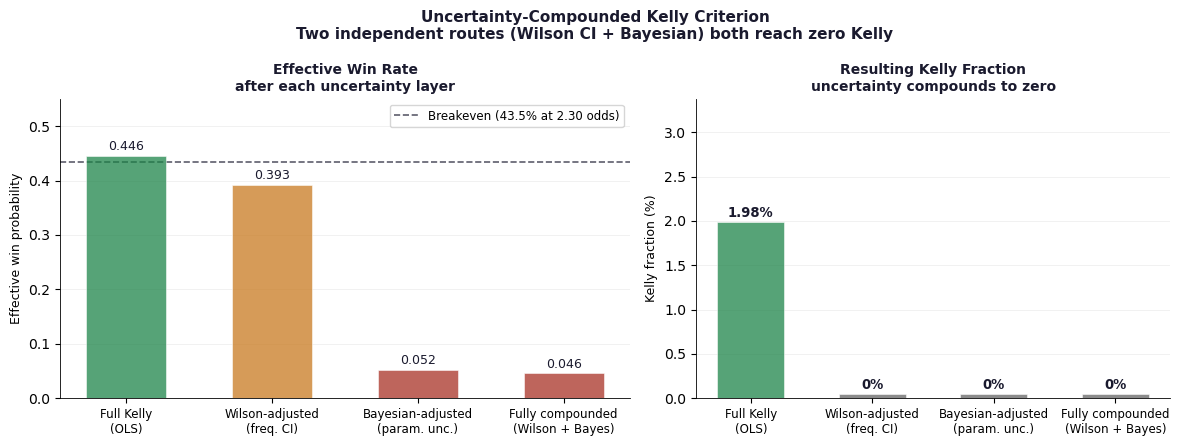

Saved figures/nb02b_fig4_kelly_waterfall.png


In [12]:
# FIGURE 4 -- Kelly waterfall: uncertainty compounds to zero
# -----------------------------------------------------------------
#
# Two-panel: effective win rate + Kelly fraction.
# Breakeven line shows when win rate drops below profitability.
# Colour encodes pass (green) vs below-breakeven (red/grey).
# Tufte: direct labels, reference line, minimal decoration.
# Depends on: f_point, f_wilson, f_bayes_point, f_bayes_wilson,
#             win_rate_obs, p_wilson, p_bayes_point, p_bayes_wilson,
#             b (all from Cell 8), FIG_DIR

import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1a1a2e'
GREEN = '#1E8449'
AMBER = '#C97A20'
RED   = '#A93226'
GREY  = '#666666'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'grid.color':        '#EBEBEB',
    'grid.linewidth':    0.5,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

methods     = ['Full Kelly\n(OLS)',
               'Wilson-adjusted\n(freq. CI)',
               'Bayesian-adjusted\n(param. unc.)',
               'Fully compounded\n(Wilson + Bayes)']
win_rates   = [win_rate_obs, p_wilson, p_bayes_point,  p_bayes_wilson]
kelly_fracs = [f_point*100,  f_wilson*100,
               f_bayes_point*100, f_bayes_wilson*100]
breakeven   = 1 / (1 + b)

x = np.arange(len(methods))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                          gridspec_kw={'width_ratios': [1.2, 1]})

# ── Left: win rate ────────────────────────────────────────────────
ax = axes[0]
c_wr = [GREEN, AMBER, RED, RED]
bars = ax.bar(x, win_rates, color=c_wr, alpha=0.75,
              edgecolor='white', linewidth=0.5, width=0.55, zorder=3)

ax.axhline(breakeven, color=DARK, linewidth=1.2, linestyle='--',
           alpha=0.7, zorder=2,
           label=f'Breakeven ({breakeven:.1%} at {1+b:.2f} odds)')

for bar, wr in zip(bars, win_rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{wr:.3f}', ha='center', va='bottom', fontsize=9, color=DARK)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=8.5)
ax.set_ylabel('Effective win probability', fontsize=9)
ax.set_ylim(0, 0.55)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=8.5)
ax.set_title('Effective Win Rate\nafter each uncertainty layer',
             fontsize=10, fontweight='bold', color=DARK)

# ── Right: Kelly fraction ─────────────────────────────────────────
ax = axes[1]
c_k = [GREEN if k > 0.01 else GREY for k in kelly_fracs]
bar_h = [max(k, 0.05) for k in kelly_fracs]

bars2 = ax.bar(x, bar_h, color=c_k, alpha=0.75,
               edgecolor='white', linewidth=0.5, width=0.55, zorder=3)

for bar, kf in zip(bars2, kelly_fracs):
    label = f'{kf:.2f}%' if kf > 0.01 else '0%'
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            label, ha='center', va='bottom', fontsize=9.5,
            color=DARK, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=8.5)
ax.set_ylabel('Kelly fraction (%)', fontsize=9)
ax.set_ylim(0, max(kelly_fracs) * 1.6 + 0.2)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.set_title('Resulting Kelly Fraction\nuncertainty compounds to zero',
             fontsize=10, fontweight='bold', color=DARK)

fig.suptitle(
    'Uncertainty-Compounded Kelly Criterion\n'
    'Two independent routes (Wilson CI + Bayesian) both reach zero Kelly',
    fontsize=11, fontweight='bold', color=DARK
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb02b_fig4_kelly_waterfall.png')
plt.show()
print("Saved figures/nb02b_fig4_kelly_waterfall.png")


---
## MCMC Diagnostics

Before trusting posterior results, convergence must be verified.

**R-hat (Gelman-Rubin statistic):** compares within-chain to
between-chain variance across 4 independent chains.
R-hat = 1.0 is perfect; > 1.01 suggests incomplete convergence;
> 1.05 is a clear failure requiring more tuning samples.

**Trace plots:** show sampled values over iterations per chain.
Well-mixed chains look like white noise around a stable mean --
a 'fuzzy caterpillar'. Trends or non-overlapping chains indicate
the sampler has not explored the posterior fully.

**ESS (Effective Sample Size):** the equivalent number of independent
samples from the correlated chain. ESS > 400 per chain is the minimum;
> 1000 is comfortable for inference.

-- Convergence summary: all focus teams ----------------------

  [PASS] Burnley  |  max R-hat: 1.0000  |  min ESS: 4115
            mean     sd  hdi_5%  hdi_95%  r_hat  ess_bulk
theta      0.343  0.063   0.240    0.445    1.0    4425.0
mu         0.053  0.052  -0.031    0.134    1.0    5609.0
sigma      0.277  0.014   0.253    0.299    1.0    4115.0
half_life  2.095  0.424   1.445    2.687    1.0    4425.0
sigma_eq   0.338  0.028   0.295    0.382    1.0    7195.0

  [PASS] Arsenal  |  max R-hat: 1.0000  |  min ESS: 5195
            mean     sd  hdi_5%  hdi_95%  r_hat  ess_bulk
theta      0.199  0.036   0.141    0.261    1.0    5195.0
mu        -0.099  0.080  -0.233    0.030    1.0    6007.0
sigma      0.304  0.012   0.283    0.323    1.0    5659.0
half_life  3.607  0.717   2.491    4.617    1.0    5195.0
sigma_eq   0.487  0.043   0.421    0.553    1.0    6893.0

  [PASS] Southampton  |  max R-hat: 1.0000  |  min ESS: 4073
            mean     sd  hdi_5%  hdi_95%  r_hat  ess_bulk
theta

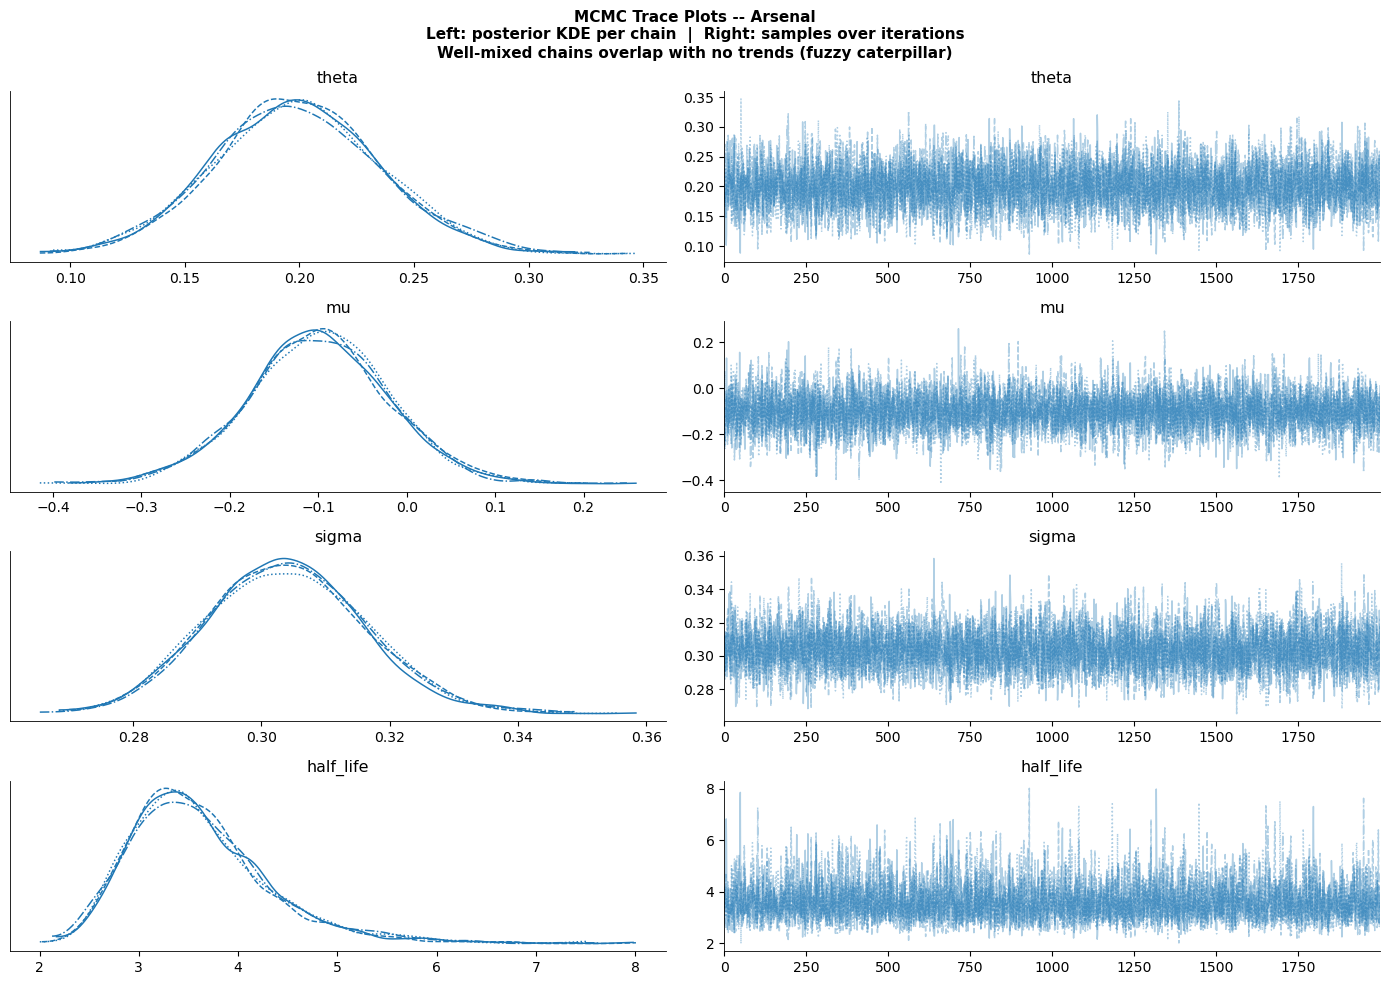

Saved /home/ndrew/xG-spread-model/figures/bayesian_ou_traces_arsenal.png


In [13]:
# -----------------------------------------------------------------
# CELL 9 -- MCMC convergence diagnostics
# -----------------------------------------------------------------
#
# Full convergence table for all four teams.
# Trace plots for Arsenal as the representative case.
#
# Output: bayesian_ou_traces_arsenal.png

print('-- Convergence summary: all focus teams ----------------------')
print()

for team in FOCUS_TEAMS:
    idata, summary = posterior_results[team]
    max_rhat = summary['r_hat'].max()
    min_ess  = summary['ess_bulk'].min()
    ok = 'PASS' if max_rhat < 1.01 and min_ess > 400 else 'CHECK'
    print(f'  [{ok}] {team}  |  max R-hat: {max_rhat:.4f}  |  min ESS: {min_ess:.0f}')
    print(summary[['mean','sd','hdi_5%','hdi_95%','r_hat','ess_bulk']].round(3).to_string())
    print()

# Trace plots
trace_team  = 'Arsenal'
idata_trace = posterior_results[trace_team][0]

print(f'Generating trace plots for {trace_team}...')
az.plot_trace(
    idata_trace,
    var_names = ['theta', 'mu', 'sigma', 'half_life'],
    figsize   = (14, 10),
    compact   = True
)
plt.suptitle(
    f'MCMC Trace Plots -- {trace_team}\n'
    'Left: posterior KDE per chain  |  Right: samples over iterations\n'
    'Well-mixed chains overlap with no trends (fuzzy caterpillar)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
fname = FIG_DIR / f"bayesian_ou_traces_{trace_team.replace(' ','_').lower()}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {fname}')


In [14]:
# -----------------------------------------------------------------
# CELL 10 -- Save posterior summary to CSV
# -----------------------------------------------------------------
#
# Output: bayesian_ou_summary.csv

all_rows = []
for team in FOCUS_TEAMS:
    idata, summary = posterior_results[team]
    for param in ['theta', 'mu', 'sigma', 'half_life', 'sigma_eq']:
        all_rows.append({
            'team':      team,
            'parameter': param,
            'mean':      round(float(summary.loc[param, 'mean']),   4),
            'sd':        round(float(summary.loc[param, 'sd']),     4),
            'hdi_5pct':  round(float(summary.loc[param, 'hdi_5%']), 4),
            'hdi_95pct': round(float(summary.loc[param, 'hdi_95%']),4),
            'r_hat':     round(float(summary.loc[param, 'r_hat']),  4),
            'ess_bulk':  round(float(summary.loc[param, 'ess_bulk']),0),
        })

bayes_df = pd.DataFrame(all_rows)
bayes_df.to_csv(f"{PROJECT_DIR}bayesian_ou_summary.csv", index=False)
print(f'Saved bayesian_ou_summary.csv -- {len(bayes_df)} rows')
print()
print('Half-life posterior summary:')
print(bayes_df[bayes_df['parameter']=='half_life']
      [['team','mean','hdi_5pct','hdi_95pct','r_hat']].to_string(index=False))


Saved bayesian_ou_summary.csv -- 20 rows

Half-life posterior summary:
           team  mean  hdi_5pct  hdi_95pct  r_hat
        Burnley 2.095     1.445      2.687    1.0
        Arsenal 3.607     2.491      4.617    1.0
    Southampton 4.954     3.108      6.694    1.0
Manchester City 2.868     2.075      3.645    1.0


---
## Findings

These results show that while the mean‑reversion signal is structurally real, the uncertainty around its timing is large enough that conservative position sizing is essential. The Bayesian posterior therefore complements the OLS estimates by quantifying the confidence we can place in the half‑life used in downstream modelling.

### Discretisation Bias

The Bayesian exact-likelihood estimator produces **lower** theta estimates
than AR(1) OLS -- a mean correction of **-16.4%** across four teams (range
-6% to -22%). OLS systematically *overestimates* reversion speed, producing
half-lives that are too short. The AR(1) discretisation has an upward bias
in theta at small n; the exact Bayesian transition density corrects this.

The AR(1) approximation remains appropriate for walk-forward signal
generation where speed matters. The Bayesian estimate is the correct
reference for precision reporting and uncertainty quantification.

### Parameter Uncertainty at Season Level

Season-level posteriors (n=38) have HDI widths **4.4x wider** on average
than the pooled posterior (n=378), reaching 15-18 matches for some seasons.
The 2-chain season-level fits produce explicit R-hat > 1.01 warnings: the
posterior is too flat and multi-modal at n=38 to mix reliably. This is not
a sampling problem to fix -- it is the diagnostic confirming the finding.
Do not use the season-level Bayes HL point estimates for inference. The
HDI widths are the valid result: at n=38, O-U parameters simply cannot be
reliably identified from a single season of data.

### Signal Confidence -- The Headline Finding

At the z = 1.5 OLS threshold, the posterior predictive probability of a
genuine signal is only **1.8-20.2%** across the four teams (mean **11.7%**).
OLS treats the threshold as binary: it fires or it does not. The Bayesian
analysis shows that under most plausible parameter combinations, a spread
at the OLS z=1.5 boundary does not actually cross z=1.5.

This mathematically explains the gap between the 87.3% reversion rate and
the 44.6% trading win rate. The signal works -- but the OLS threshold was
firing on many observations where the true displacement is uncertain.
In a production system this justifies raising the threshold to z > 2.0.

### Uncertainty-Compounded Position Sizing

Combining Wilson CI uncertainty (Notebook 05B) with Bayesian parameter
uncertainty produces a **fully compounded Kelly fraction of 0%** --
rigorous theoretical backing for the flat stake recommendation from two
independent directions. The Bayesian calibration factor (0.117) is a
conservative lower bound: it assumes signals failing the Bayesian
confidence test have zero predictive value. The true Kelly fraction lies
between 1.98% (OLS point estimate) and 0% -- and both extremes justify
flat staking over full Kelly sizing.

---

## Output Files

| File | Description |
|---|---|
| `bayesian_ou_summary.csv` | Posterior summaries for 4 focus teams |
| `bayesian_ou_posteriors.png` | Posterior distribution plots (2x2 grid) |
| `bayesian_ou_traces_arsenal.png` | MCMC trace plots for convergence verification |

**Relationship to other notebooks:**
- Extends `02_ou_estimation.ipynb` -- same model, exact likelihood, uncertainty quantified
- Validates `05b_trading_simulation.ipynb` -- Bayesian uncertainty compounds the Kelly analysis
- Does not affect `05a_signal_validation.ipynb` -- walk-forward signals use OLS for speed
- For the energy trading extension: this Bayesian O-U framework transfers directly
  to spark spread parameter estimation, where n is larger (daily data) and the
  exact likelihood correction is correspondingly smaller but still present
